In [1]:
#from sympy import symbols, cos, sin, Matrix, pi, sqrt, eye, zeros, simplify
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # ← これが必要
plt.rcParams['font.family'] = 'Times New Roman'

## Defining homogeneous matrix for ball joint model [LM2025]

In [2]:
# Defining variables
theta = sp.symbols('theta')
phi = sp.symbols('phi')
w = sp.symbols('w')
d = sp.symbols('d')
h = sp.symbols('h')
# x, y, z = symbols('x y z')

# Rotation vector R_y(theta) * R_z(phi)
R = sp.Matrix([
    [sp.cos(theta) * sp.cos(phi), -sp.cos(theta) * sp.sin(phi), sp.sin(theta)],
    [sp.sin(phi), sp.cos(phi), 0],
    [-sp.sin(theta) * sp.cos(phi), sp.sin(theta) * sp.sin(phi), sp.cos(theta)]
])

# translation vector
t = sp.Matrix([0, 0, 0])

# homogeneous matrix
T = R.row_join(t)
T = T.col_join(sp.Matrix([[0, 0, 0, 1]]))

# display
# sp.pprint(T, use_unicode=True)
display(T)

Matrix([
[ cos(phi)*cos(theta), -sin(phi)*cos(theta), sin(theta), 0],
[            sin(phi),             cos(phi),          0, 0],
[-sin(theta)*cos(phi),  sin(phi)*sin(theta), cos(theta), 0],
[                   0,                    0,          0, 1]])

## Ligament attachment

In [3]:
#Local coordinates
#Cruciate ligaments
p_acl_f = sp.Matrix([-d/2, 0,  0])
p_acl_t = sp.Matrix([ d/2, 0, -h])
p_pcl_f = sp.Matrix([ d/2, 0,  0])
p_pcl_t = sp.Matrix([-d/2, 0, -h])

#Collateral ligaments
p_lcl_f = sp.Matrix([12, 33,  35])
p_lcl_t = sp.Matrix([-5, 40,  -30])
p_mcl_f = sp.Matrix([12, -33,  35])
p_mcl_t = sp.Matrix([-5, -40,  -30])


p_acl_f_hg = p_acl_f.col_join(sp.Matrix([1]))
p_acl_t_hg = p_acl_t.col_join(sp.Matrix([1]))
p_pcl_f_hg = p_pcl_f.col_join(sp.Matrix([1]))
p_pcl_t_hg = p_pcl_t.col_join(sp.Matrix([1]))

p_lcl_f_hg = p_lcl_f.col_join(sp.Matrix([1]))
p_lcl_t_hg = p_lcl_t.col_join(sp.Matrix([1]))
p_mcl_f_hg = p_mcl_f.col_join(sp.Matrix([1]))
p_mcl_t_hg = p_mcl_t.col_join(sp.Matrix([1]))


P_ACL_matrix = sp.Matrix([p_acl_f_hg]).row_join(sp.Matrix([p_acl_t_hg])).row_join(sp.Matrix([p_pcl_f_hg]).row_join(sp.Matrix([p_pcl_t_hg])))
P_LCL_matrix = sp.Matrix([p_lcl_f_hg]).row_join(sp.Matrix([p_lcl_t_hg])).row_join(sp.Matrix([p_lcl_f_hg]).row_join(sp.Matrix([p_lcl_t_hg])))


display(P_ACL_matrix)


#global coordinates
p_acl_t_hg = T*p_acl_t_hg
p_pcl_t_hg = T*p_pcl_t_hg
p_lcl_t_hg = T*p_lcl_t_hg
p_mcl_t_hg = T*p_mcl_t_hg


display(p_acl_t_hg)
display(p_pcl_t_hg)
display(p_lcl_t_hg)
display(p_mcl_t_hg)

Matrix([
[-d/2, d/2, d/2, -d/2],
[   0,   0,   0,    0],
[   0,  -h,   0,   -h],
[   1,   1,   1,    1]])

Matrix([
[ d*cos(phi)*cos(theta)/2 - h*sin(theta)],
[                           d*sin(phi)/2],
[-d*sin(theta)*cos(phi)/2 - h*cos(theta)],
[                                      1]])

Matrix([
[-d*cos(phi)*cos(theta)/2 - h*sin(theta)],
[                          -d*sin(phi)/2],
[ d*sin(theta)*cos(phi)/2 - h*cos(theta)],
[                                      1]])

Matrix([
[-40*sin(phi)*cos(theta) - 30*sin(theta) - 5*cos(phi)*cos(theta)],
[                                      -5*sin(phi) + 40*cos(phi)],
[ 40*sin(phi)*sin(theta) + 5*sin(theta)*cos(phi) - 30*cos(theta)],
[                                                              1]])

Matrix([
[ 40*sin(phi)*cos(theta) - 30*sin(theta) - 5*cos(phi)*cos(theta)],
[                                      -5*sin(phi) - 40*cos(phi)],
[-40*sin(phi)*sin(theta) + 5*sin(theta)*cos(phi) - 30*cos(theta)],
[                                                              1]])

## Ligament vector computation

In [4]:
v_acl = p_acl_t_hg - p_acl_f_hg
v_pcl = p_pcl_t_hg - p_pcl_f_hg

v_lcl = p_lcl_t_hg - p_lcl_f_hg
v_mcl = p_mcl_t_hg - p_mcl_f_hg

display(v_acl)
display(v_pcl)
display(v_lcl)
display(v_mcl)

L_acl = v_acl.norm()
L_pcl = v_pcl.norm()
L_lcl = v_lcl.norm()
L_mcl = v_mcl.norm()

display(L_acl)
display(L_pcl)
display(L_lcl)
display(L_mcl)

Matrix([
[d*cos(phi)*cos(theta)/2 + d/2 - h*sin(theta)],
[                                d*sin(phi)/2],
[     -d*sin(theta)*cos(phi)/2 - h*cos(theta)],
[                                           0]])

Matrix([
[-d*cos(phi)*cos(theta)/2 - d/2 - h*sin(theta)],
[                                -d*sin(phi)/2],
[       d*sin(theta)*cos(phi)/2 - h*cos(theta)],
[                                            0]])

Matrix([
[-40*sin(phi)*cos(theta) - 30*sin(theta) - 5*cos(phi)*cos(theta) - 12],
[                                      -5*sin(phi) + 40*cos(phi) - 33],
[ 40*sin(phi)*sin(theta) + 5*sin(theta)*cos(phi) - 30*cos(theta) - 35],
[                                                                   0]])

Matrix([
[ 40*sin(phi)*cos(theta) - 30*sin(theta) - 5*cos(phi)*cos(theta) - 12],
[                                      -5*sin(phi) - 40*cos(phi) + 33],
[-40*sin(phi)*sin(theta) + 5*sin(theta)*cos(phi) - 30*cos(theta) - 35],
[                                                                   0]])

sqrt(Abs(d*sin(phi))**2/4 + Abs(d*sin(theta)*cos(phi)/2 + h*cos(theta))**2 + Abs(d*cos(phi)*cos(theta)/2 + d/2 - h*sin(theta))**2)

sqrt(Abs(d*sin(phi))**2/4 + Abs(d*sin(theta)*cos(phi)/2 - h*cos(theta))**2 + Abs(d*cos(phi)*cos(theta)/2 + d/2 + h*sin(theta))**2)

sqrt(Abs(5*sin(phi) - 40*cos(phi) + 33)**2 + Abs(40*sin(phi)*sin(theta) + 5*sin(theta)*cos(phi) - 30*cos(theta) - 35)**2 + Abs(40*sin(phi)*cos(theta) + 30*sin(theta) + 5*cos(phi)*cos(theta) + 12)**2)

sqrt(Abs(5*sin(phi) + 40*cos(phi) - 33)**2 + Abs(40*sin(phi)*sin(theta) - 5*sin(theta)*cos(phi) + 30*cos(theta) + 35)**2 + Abs(-40*sin(phi)*cos(theta) + 30*sin(theta) + 5*cos(phi)*cos(theta) + 12)**2)

## Plot ligament length (2D)

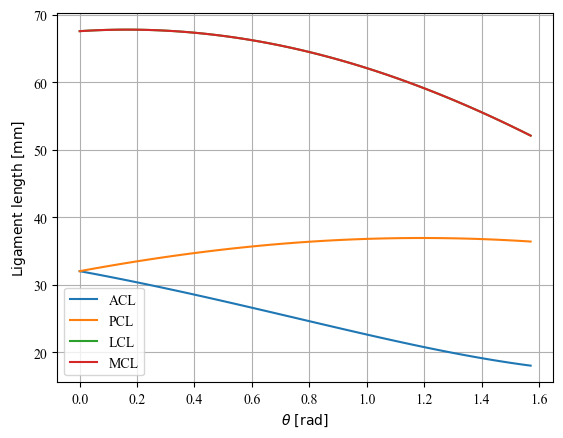

In [5]:
ligament_list = []
ligament_list.append(v_acl)
ligament_list.append(v_pcl)
ligament_list.append(v_lcl)
ligament_list.append(v_mcl)

# theta の値を指定してノルムを計算
theta_vals = np.linspace(0.0001, 1.0/2.0 *np.pi, 100)

norm_list = []
norm_list.append(L_acl)
norm_list.append(L_pcl)
norm_list.append(L_lcl)
norm_list.append(L_mcl)

names_list = []
names_list.append('ACL')
names_list.append('PCL')
names_list.append('LCL')
names_list.append('MCL')

norm_vals_list = []
for i_num in range(len(ligament_list)):
    norm_vals = [norm_list[i_num].subs({d: 20, h: 25, theta: val, phi: 0.0}).evalf() for val in theta_vals]
    norm_vals_list.append(norm_vals)

# グラフのプロット
for i_num in range(len(ligament_list)):
    #plt.plot(theta_vals, norm_vals_list[i_num], label=f'#{i_num}')
    plt.plot(theta_vals, norm_vals_list[i_num], label=f'{names_list[i_num]}')

#plt.title('Norm of the vector y as a function of theta')
# plt.xlabel('Theta (radians)')
# plt.ylabel('Ligament length [mm]')
plt.xlabel(r'$\theta~\left[\mathrm{rad} \right]$')
plt.ylabel(r'$\mathrm{Ligament\ length\ [mm]}$')
plt.grid()
plt.legend()
plt.show()

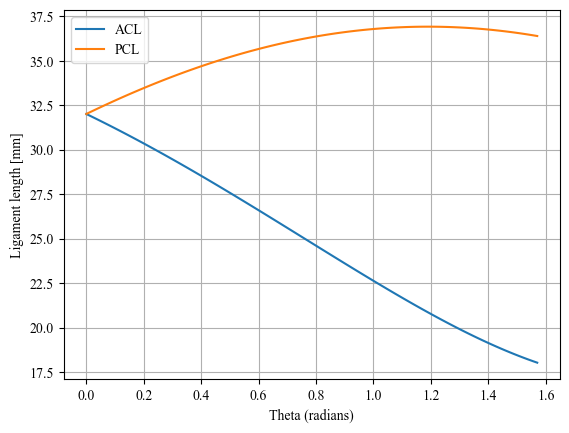

In [6]:
ligament_list = []
ligament_list.append(v_acl)
ligament_list.append(v_pcl)

# theta の値を指定してノルムを計算
theta_vals = np.linspace(0.0001, 1.0/2.0 *np.pi, 100)

norm_list = []
norm_list.append(L_acl)
norm_list.append(L_pcl)

names_list = []
names_list.append('ACL')
names_list.append('PCL')

norm_vals_list = []
for i_num in range(len(ligament_list)):
    norm_vals = [norm_list[i_num].subs({d: 20, h: 25, theta: val, phi: 0.0}).evalf() for val in theta_vals]
    norm_vals_list.append(norm_vals)

# グラフのプロット
for i_num in range(len(ligament_list)):
    #plt.plot(theta_vals, norm_vals_list[i_num], label=f'#{i_num}')
    plt.plot(theta_vals, norm_vals_list[i_num], label=f'{names_list[i_num]}')

#plt.title('Norm of the vector y as a function of theta')
plt.xlabel('Theta (radians)')
plt.ylabel('Ligament length [mm]')
plt.grid()
plt.legend()
plt.show()

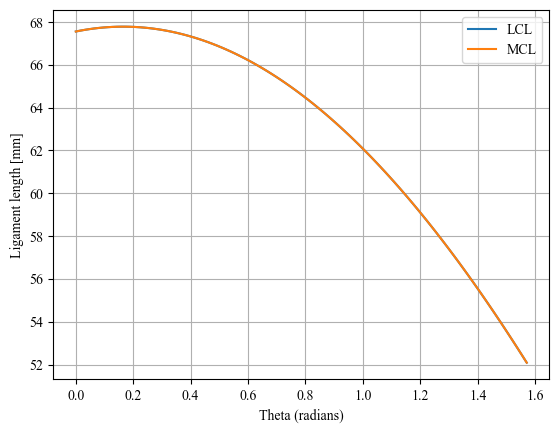

In [7]:
ligament_list = []
ligament_list.append(v_lcl)
ligament_list.append(v_mcl)

# theta の値を指定してノルムを計算
theta_vals = np.linspace(0.0001, 1.0/2.0 *np.pi, 100)

norm_list = []
norm_list.append(L_lcl)
norm_list.append(L_mcl)

names_list = []
names_list.append('LCL')
names_list.append('MCL')

norm_vals_list = []
for i_num in range(len(ligament_list)):
    norm_vals = [norm_list[i_num].subs({d: 20, h: 25, theta: val, phi: 0.0}).evalf() for val in theta_vals]
    norm_vals_list.append(norm_vals)

# グラフのプロット
for i_num in range(len(ligament_list)):
    #plt.plot(theta_vals, norm_vals_list[i_num], label=f'#{i_num}')
    plt.plot(theta_vals, norm_vals_list[i_num], label=f'{names_list[i_num]}')

#plt.title('Norm of the vector y as a function of theta')
plt.xlabel('Theta (radians)')
plt.ylabel('Ligament length [mm]')
plt.grid()
plt.legend()
plt.show()

## Plot ligament length (3D)

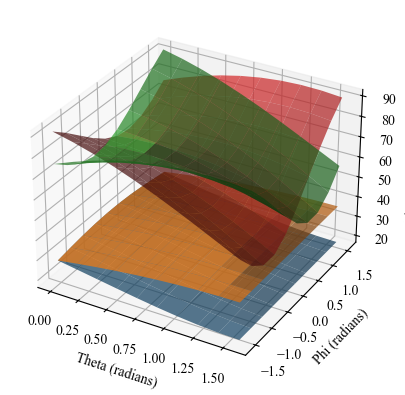

In [8]:
ligament_list = []
ligament_list.append(v_acl)
ligament_list.append(v_pcl)
ligament_list.append(v_lcl)
ligament_list.append(v_mcl)

# theta の値を指定してノルムを計算
theta_vals = np.linspace(0.0001, 1.0/2.0 *np.pi, 10)
phi_vals = np.linspace(-1.0/2.0 *np.pi, 1.0/2.0 *np.pi, 10)

norm_list = []
norm_list.append(L_acl)
norm_list.append(L_pcl)
norm_list.append(L_lcl)
norm_list.append(L_mcl)

Theta, Phi = np.meshgrid(theta_vals, phi_vals)

norm_vals_list = []


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i_num in range(len(ligament_list)):
    Z = np.array([
        [norm_list[i_num].subs({d: 20, h: 25, theta: th, phi: ph}).evalf()
         for th in theta_vals]
        for ph in phi_vals
    ], dtype=float)
    ax.plot_surface(Theta, Phi, Z, label=f'#{i_num}', alpha=0.7)


ax.set_xlabel('Theta (radians)')
ax.set_ylabel('Phi (radians)')
ax.set_zlabel('Ligament length [mm]')
plt.show()

## Cruciate ligaments 3D Plot

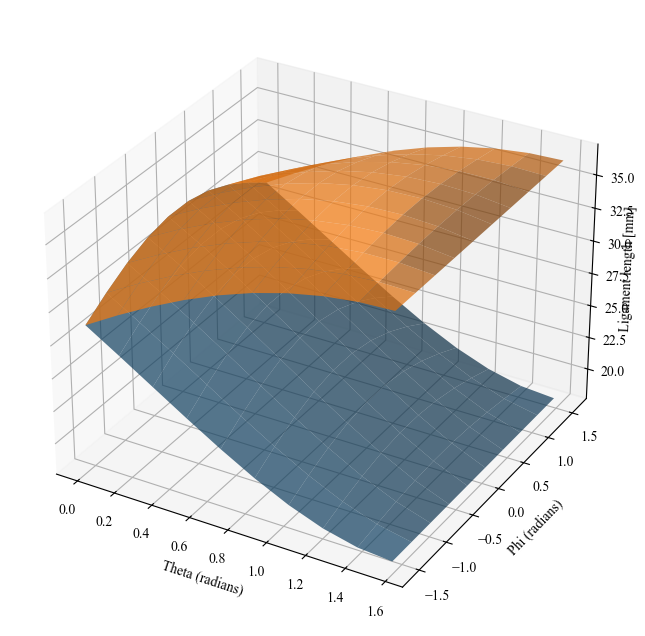

In [9]:
ligament_list = []
ligament_list.append(v_acl)
ligament_list.append(v_pcl)

# theta の値を指定してノルムを計算
theta_vals = np.linspace(0.0001, 1.0/2.0 *np.pi, 10)
phi_vals = np.linspace(-1.0/2.0 *np.pi, 1.0/2.0 *np.pi, 10)

norm_list = []
norm_list.append(L_acl)
norm_list.append(L_pcl)

Theta, Phi = np.meshgrid(theta_vals, phi_vals)

norm_vals_list = []


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

for i_num in range(len(ligament_list)):
    Z = np.array([
        [norm_list[i_num].subs({d: 20, h: 25, theta: th, phi: ph}).evalf()
         for th in theta_vals]
        for ph in phi_vals
    ], dtype=float)
    ax.plot_surface(Theta, Phi, Z, label=f'#{i_num}', alpha=0.7)


ax.set_xlabel('Theta (radians)')
ax.set_ylabel('Phi (radians)')
ax.set_zlabel('Ligament length [mm]', labelpad=-5)
plt.show()

## Collateral ligaments 3D Plot

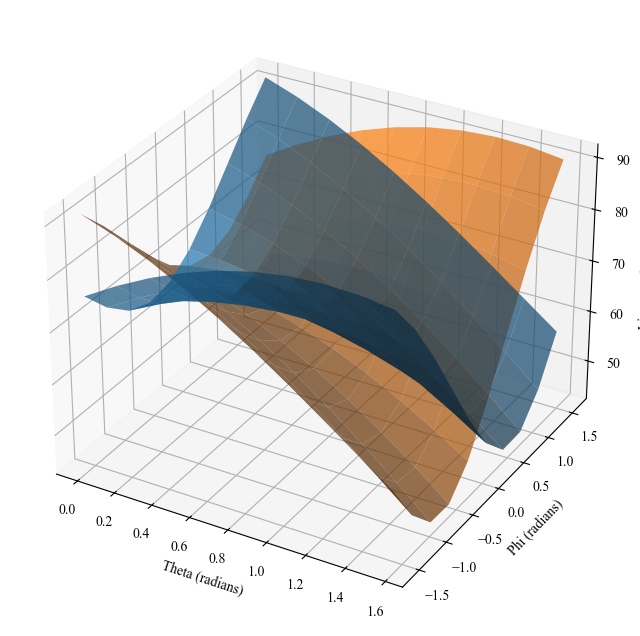

In [10]:
ligament_list = []
ligament_list.append(v_lcl)
ligament_list.append(v_mcl)

# theta の値を指定してノルムを計算
theta_vals = np.linspace(0.0001, 1.0/2.0 *np.pi, 10)
phi_vals = np.linspace(-1.0/2.0 *np.pi, 1.0/2.0 *np.pi, 10)

norm_list = []
norm_list.append(L_lcl)
norm_list.append(L_mcl)

Theta, Phi = np.meshgrid(theta_vals, phi_vals)

norm_vals_list = []


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

for i_num in range(len(ligament_list)):
    Z = np.array([
        [norm_list[i_num].subs({d: 20, h: 25, theta: th, phi: ph}).evalf()
         for th in theta_vals]
        for ph in phi_vals
    ], dtype=float)
    ax.plot_surface(Theta, Phi, Z, label=f'#{i_num}', alpha=0.7)


ax.set_xlabel('Theta (radians)')
ax.set_ylabel('Phi (radians)')
ax.set_zlabel('Ligament length [mm]')
plt.show()

## Substitution example

In [11]:
xaxis = sp.Matrix([1, 0, 0])
display(xaxis)

T_phi_sub = T.subs(phi, 0)
display(T_phi_sub)

T_both_sub = T.subs({theta: sp.pi/4, phi: sp.pi/3})
display(T_both_sub)

display(R.subs({theta: sp.pi/2, phi: sp.pi/2}))
display(R.subs({theta: sp.pi/2, phi: sp.pi/2})*xaxis)

Matrix([
[1],
[0],
[0]])

Matrix([
[ cos(theta), 0, sin(theta), 0],
[          0, 1,          0, 0],
[-sin(theta), 0, cos(theta), 0],
[          0, 0,          0, 1]])

Matrix([
[ sqrt(2)/4, -sqrt(6)/4, sqrt(2)/2, 0],
[ sqrt(3)/2,        1/2,         0, 0],
[-sqrt(2)/4,  sqrt(6)/4, sqrt(2)/2, 0],
[         0,          0,         0, 1]])

Matrix([
[0, 0, 1],
[1, 0, 0],
[0, 1, 0]])

Matrix([
[0],
[1],
[0]])